In [6]:
import scanpy as sc
from pathlib import Path

In [7]:
INDIR = Path.home()/'project/crc-pm/result/latest.h5ad'
adata = sc.read_h5ad(INDIR)
adata_imu = adata[adata.obs['Compartment'] == 'Immune']
del adata

In [8]:
sc.pp.neighbors(
    adata_imu,
    use_rep="X_scVI",
    n_neighbors=20,
    metric="cosine",
    random_state=42,
)

sc.tl.umap(
    adata_imu,
    min_dist=0.25,
    random_state=2026,)

# use different res
leiden_res = [0.25, 0.5, 1.0,1.5]
for i in leiden_res:
    sc.tl.leiden(adata_imu, key_added=f"leiden_res{i}", resolution=i, flavor="igraph", n_iterations=2)


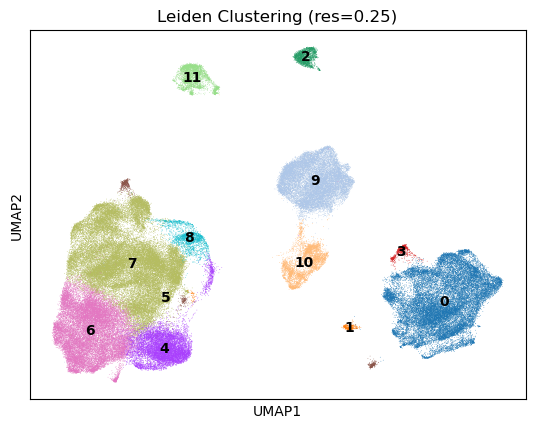

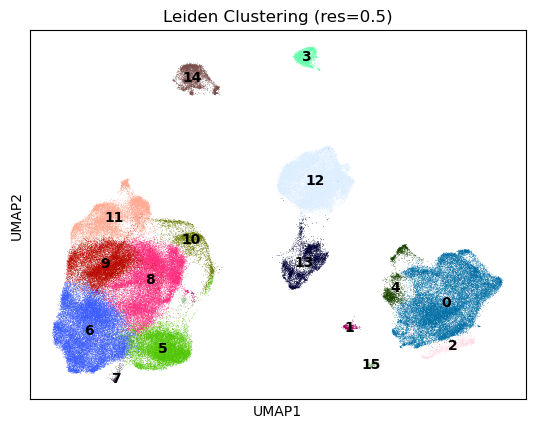

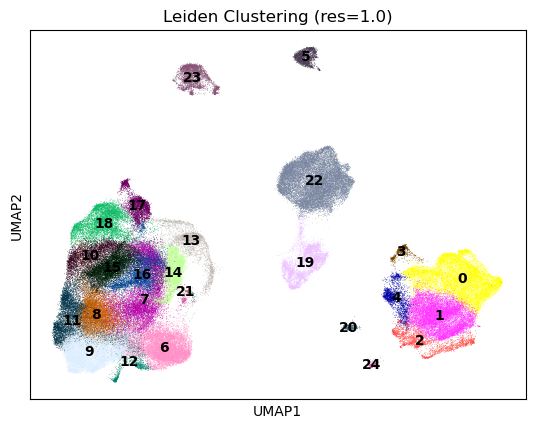

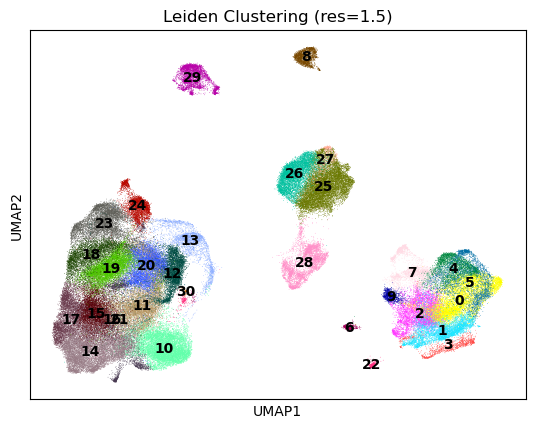

In [9]:
for i in leiden_res:
    sc.pl.umap(
        adata_imu,
        color=f"leiden_res{i}",
        legend_loc="on data",
        title=f"Leiden Clustering (res={i})",
    )

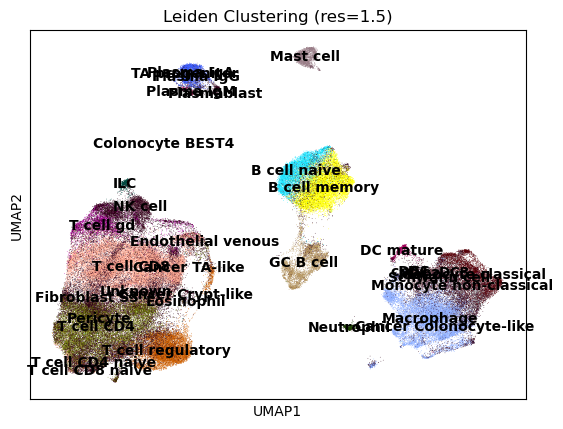

In [10]:
sc.pl.umap(
        adata_imu,
        color='scANVI_CellType',
        legend_loc="on data",
        title=f"Leiden Clustering (res={i})",
    )